# Same Product? The Alignment Cookbook on GLiNER2.5-Decide

**TypeSafe's [entity-alignment cookbook](https://docs.typesafe.ai/cookbooks/entity_alignment) — 450 candidate
pairs from two beer catalogues, one `Score` and three `Noul`s per pair, routed to *merge*, *curator* or
*leave unlinked* with no fitted threshold — reproduced with GLiNER2.5-Decide in place of Jev. Local, no API
key.**

The cookbook's design is worth stating exactly, because it is what is being tested. A cheap blocking pass
has already picked 450 pairs from the Magellan Beer benchmark. For each pair, one request carries both
entities as state and four questions: a `Score` over three worded levels — *two different products*,
*closely related products that may or may not be the same one*, *one and the same product* — and three
`Noul`s asking whether the name, the brewery and the style match. `route()` rounds the score to the nearest
level. There is no threshold constant anywhere: the wording of the levels *is* the decision, and it can be
written before seeing a single score. Jev (`jev-1.12`) routes 40 pairs to `assert sameAs`, 50 to the
curator and 360 to `leave unlinked`.

This notebook runs the same 450 pairs, under the same ids, through the same four questions — moved onto
Decide's API as literally as it allows — with the same `route()` and the same chart. Then it does the one
thing the cookbook does not: score the answers against `known_same_as`, the benchmark's own label, which
the cookbook's data carries and never uses — Decide's first, then Jev's, re-run on every pair.

[Notebook 15](15_gliner_decide.ipynb) §3.6 already found that Decide cannot adjudicate whether two
*mentions* in free text are one entity. This is the same question in the friendliest form it can take:
two short structured records side by side, on a published benchmark, with a train split to fit against if
it comes to that.

| § | |
|---|---|
| 1 | the cookbook's questions as a Decide schema, and its four worked pairs |
| 2 | routing all 450 pairs with the cookbook's rule |
| 3 | whether there is signal in the answers, against `known_same_as` and a string baseline |
| 4 | how much of the outcome is the wording |
| 5 | the threshold the cookbook did not need, fitted on train and checked on held-out pairs |
| 6 | Jev itself on the same 450 pairs, scored against the same labels |

The short version: the translation holds and the routing rule does not. Decide's answers *order* the pairs
but do not *place* them on the levels, so the threshold the cookbook designed away comes back, and has to
be fitted from labels. Jev, asked the same questions about the same pairs, needs no threshold, and every
pair it merges is a match.

Needs the Decide weights (~1.9 GB, cached if notebook 15 has run) and a one-time 160 KB download of the
benchmark into `output/beer/`. §6 also needs `TYPESAFE_API_KEY` — in the environment or in `.env` — or
the responses a previous run cached in `output/typesafe_cache/`; with neither it skips itself.

## 0. Setup

In [1]:
import os, sys, time, json, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 210)
pd.set_option("display.max_colwidth", 60)

import kgx.decide as kd
import kgx.alignment as ka
from kgx.data.beer import load_pairs, URL

PAIRS = load_pairs()
BY_ID = {pair["id"]: pair for pair in PAIRS}
GOLD = [pair["known_same_as"] for pair in PAIRS]

print(f"{len(PAIRS)} candidate pairs from {URL.rsplit('/', 1)[-1]}, {sum(GOLD)} of them the same beer")
print("   " + ", ".join(f"{s} {sum(p['split'] == s for p in PAIRS)} ({sum(p['known_same_as'] for p in PAIRS if p['split'] == s)} matches)"
                       for s in ("train", "valid", "test")))
print("\nThe first one, as the model will see it:")
print(json.dumps({k: PAIRS[0][k] for k in ("entity_a", "entity_b")}, indent=2))

450 candidate pairs from beer_exp_data.zip, 68 of them the same beer
   train 268 (40 matches), valid 91 (14 matches), test 91 (14 matches)

The first one, as the model will see it:
{
  "entity_a": {
    "name": "C N Red Imperial Red Ale",
    "brewery": "Redwood Lodge",
    "style": "American Amber / Red Ale",
    "abv": "8.10 %"
  },
  "entity_b": {
    "name": "Kinetic Infrared Imperial Red Ale",
    "brewery": "Kinetic Brewing Company",
    "style": "American Strong Ale",
    "abv": "9.30 %"
  }
}


The same first pair the cookbook prints, and the same ids: the cookbook's `candidate_pairs.json` is the
benchmark's train, valid and test pairs concatenated in that order, which `kgx.data.beer` rebuilds from the
published tables. The text is left as published — `&#40; Ohio &#41;`, `Poor Richard 's Ale`, `TrÃ ¶ egs` —
because the cookbook leaves it that way too.

In [2]:
judge = kd.DecideJudge()
print(judge)

🧠 Model Configuration
Encoder model      : microsoft/deberta-v3-large
Counting layer     : count_lstm
Token pooling      : first


<DecideJudge fastino/GLiNER2.5-Decide 486M params on cpu, loaded in 7.0s>


---

## 1. The cookbook's questions, as Decide sees them

The translation, piece by piece:

| TypeSafe (the cookbook) | GLiNER2.5-Decide (here) |
|---|---|
| state: `{"entity_a": …, "entity_b": …}` | the same JSON, as the text |
| `Score` with three level criteria | a single-label task, the three criteria as label descriptions |
| the `Score`'s instructions | the task's instruction |
| `Noul` | a `yes`/`no` task with the question as its instruction — the model card's "question over a passage" |
| four questions in one request | four tasks in one schema: one forward pass |
| `score`: probability-weighted position on the levels | the same, computed from Decide's distribution (`ka.level_score`) |

Two places where the translation is not neutral. A Decide label needs a *name*, where a TypeSafe level is
only its criterion, so the levels are named for the relation they describe: `different product`,
`related product`, `same product`. And a TypeSafe question id is never sent to the model, while a GLiNER2
task name is encoded into the prompt (notebook 15 §2.5): `link_state`, the cookbook's id, is now something
Decide reads. §4 measures both.

In [3]:
schema = ka.cookbook_schema()
for spec in schema.task_specs:
    print(f"task {spec.name!r}    instruction: {spec.instruction}")
    for label in spec.labels:
        print(f"    label {label.name!r}" + (f"  —  {label.description}" if label.description else ""))

task 'link_state'    instruction: How do the two entity descriptions relate as products?
    label 'different product'  —  They describe two different products.
    label 'related product'  —  They describe closely related products that may or may not be the same one: a variant, a special edition, or a name that could plausibly refer to either.
    label 'same product'  —  They describe one and the same product.
task 'same_name'    instruction: Do the two entities state the same beer name?
    label 'yes'
    label 'no'
task 'same_brewery'    instruction: Are the two entities from the same brewery?
    label 'yes'
    label 'no'
task 'same_style'    instruction: Do the two entities describe the same beer style?
    label 'yes'
    label 'no'


### 1.1 The four worked pairs

The cookbook shows four pairs: `c446` is one product, `c427` two, and two land in the middle level for
different reasons — `c100` has the same name and brewery but the sites word its style differently, `c428`
pairs a beer with a fruit-and-hop variant of it. Jev's lines here are as published (`jev-1.12`,
2026-08-11); §6 runs Jev on all 450 pairs.

In [4]:
JEV = {  # the cookbook's published answers for its four worked pairs
    "c446": {"score": 1.94, "confidence": 0.92, "same_name": 0.97, "same_brewery": 0.99, "same_style": 0.81},
    "c427": {"score": 0.03, "confidence": 0.95, "same_name": 0.02, "same_brewery": 0.09, "same_style": 0.08},
    "c100": {"score": 1.30, "confidence": 0.27, "same_name": 0.95, "same_brewery": 0.94, "same_style": 0.35},
    "c428": {"score": 1.10, "confidence": 0.77, "same_name": 0.63, "same_brewery": 0.98, "same_style": 0.74},
}

def show(judgment):
    """The cookbook's show(), with Decide's line and Jev's published line side by side."""
    pair = BY_ID[judgment.pair_id]
    print(f"{judgment.pair_id}  known_same_as={pair['known_same_as']}")
    for side in ("entity_a", "entity_b"):
        e = pair[side]
        print(f"    {e['name'][:44]:<46}{e['brewery'][:30]:<32}{e['style'][:22]}")
    rows = [("Decide", judgment.score, judgment.confidence, judgment.properties)]
    if judgment.pair_id in JEV:
        j = JEV[judgment.pair_id]
        rows.append(("Jev", j["score"], j["confidence"], j))
    for who, s, c, nouls in rows:
        print(f"    {who:<7}score {s:.2f}  confidence {c:.2f}  ->  {ka.route(s):<16}"
              f"name {nouls['same_name']:.2f}   brewery {nouls['same_brewery']:.2f}   "
              f"style {nouls['same_style']:.2f}")
    print("    Decide's levels: " + "   ".join(f"{k} {v:.2f}" for k, v in judgment.probabilities.items()))

four = ka.align(judge, [BY_ID[pair_id] for pair_id in JEV])
for judgment in four:
    show(judgment)
    print()

c446  known_same_as=True
    Thomas Hooker Old Marley Barleywine           Thomas Hooker Brewing Company   American Barleywine
    Thomas Hooker Old Marley Barleywine           Thomas Hooker Brewing Company   Barley Wine
    Decide score 0.88  confidence 0.06  ->  curator queue   name 0.44   brewery 0.66   style 0.43
    Jev    score 1.94  confidence 0.92  ->  assert sameAs   name 0.97   brewery 0.99   style 0.81
    Decide's levels: different product 0.38   related product 0.36   same product 0.26

c427  known_same_as=False
    Frost Quake Bourbon Barrel Aged Barley Wine   Wellington County Brewery       American Barleywine
    Lompoc Bourbon Barrel Aged Proletariat Red A  Lompoc Brewing                  Amber Ale
    Decide score 0.83  confidence 0.11  ->  curator queue   name 0.34   brewery 0.40   style 0.38
    Jev    score 0.03  confidence 0.95  ->  leave unlinked  name 0.02   brewery 0.09   style 0.08
    Decide's levels: different product 0.41   related product 0.36   same produ

All four come back with a score in the 0.8s, all four go to the curator, and the reason is visible in the
last line of each: Decide spreads its probability over the three levels almost evenly, a little more on
`different product` than on `same product`, whatever the pair. `c446` is two copies of the same record up
to the style wording and a trailing `.00` in the ABV, and it gets the same shape as `c427`, which shares
little beyond the words *Bourbon Barrel Aged*.

The `Noul`s are no better placed. Asked whether *Thomas Hooker Old Marley Barleywine* and *Thomas Hooker
Old Marley Barleywine* state the same beer name, Decide answers `no` (P(yes) below 0.5). §3.1 checks that
across every pair whose strings are identical.

---

## 2. Route every pair

The cookbook's loop, chart and summary, unchanged apart from the judge — one forward pass per pair, four
tasks each.

In [5]:
t0 = time.perf_counter()
judged = ka.align(judge, PAIRS)
align_s = time.perf_counter() - t0
JUDGED = {j.pair_id: j for j in judged}
print(f"{len(judged)} pairs, four questions each, in {align_s:.1f}s on {judge.classifier.device} "
      f"({1000 * align_s / len(judged):.0f} ms a pair)")
print("the four pairs from §1.1 get the same answers inside the full batch:",
      all(abs(JUDGED[j.pair_id].score - j.score) < 1e-6 for j in four))

scores = [j.score for j in judged]
by_outcome = {name: [] for name in ka.OUTCOME.values()}
for pair, s in zip(PAIRS, scores):
    by_outcome[ka.route(s)].append(pair["id"])

450 pairs, four questions each, in 71.3s on cpu (158 ms a pair)
the four pairs from §1.1 get the same answers inside the full batch: True


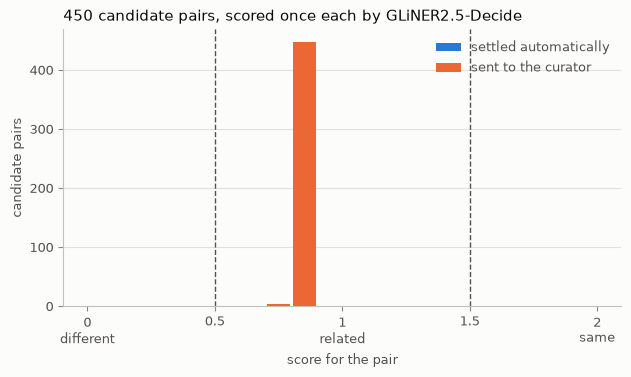

,Decide,Jev (published)
outcome,,
assert sameAs,0,40
curator queue,450,50
leave unlinked,0,360


scores span 0.73 – 0.90; confidence is at most 0.23


In [6]:
# The cookbook's chart, verbatim apart from the title.
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, BLUE, ORANGE = "#e1e0d9", "#c3c2b7", "#2a78d6", "#eb6834"

BINS, TOP = 20, len(ka.LEVELS) - 1
counts = [0] * BINS
for s in scores:
    counts[min(int(s / TOP * BINS), BINS - 1)] += 1
centers = [(i + 0.5) / BINS * TOP for i in range(BINS)]
queued = [c if ka.route(x) == "curator queue" else 0 for c, x in zip(counts, centers)]
settled = [c if ka.route(x) != "curator queue" else 0 for c, x in zip(counts, centers)]

fig, ax = plt.subplots(figsize=(7.2, 3.6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.tick_params(colors=MUTED, labelcolor=INK2, labelsize=9)
ax.set_axisbelow(True)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.bar(centers, settled, width=TOP / BINS * 0.9, color=BLUE, label="settled automatically")
ax.bar(centers, queued, width=TOP / BINS * 0.9, color=ORANGE, label="sent to the curator")
for edge in (0.5, 1.5):
    ax.axvline(edge, color=INK2, linewidth=1, linestyle="--")
ax.set_xticks([0, 0.5, 1, 1.5, 2])
ax.set_xticklabels(["0\ndifferent", "0.5", "1\nrelated", "1.5", "2\nsame"])
ax.set_xlabel("score for the pair", color=INK2, fontsize=9)
ax.set_ylabel("candidate pairs", color=INK2, fontsize=9)
ax.set_title(f"{len(PAIRS)} candidate pairs, scored once each by GLiNER2.5-Decide",
             loc="left", color=INK, fontsize=11)
ax.legend(frameon=False, labelcolor=INK2, fontsize=9)
plt.show()

JEV_COUNTS = {"assert sameAs": 40, "curator queue": 50, "leave unlinked": 360}  # as published
display(pd.DataFrame([{"outcome": name, "Decide": len(by_outcome[name]),
                       "Jev (published)": JEV_COUNTS[name]}
                      for name in ("assert sameAs", "curator queue", "leave unlinked")]).set_index("outcome"))
print(f"scores span {min(scores):.2f} – {max(scores):.2f}; "
      f"confidence is at most {max(j.confidence for j in judged):.2f}")

**Every pair goes to the curator.** Where Jev settles 400 of 450 automatically, Decide settles none: every
score falls between the two cut points, inside a band less than two tenths wide.

That is not a coincidence of wording; it is what the score is. A `Score` is the probability-weighted
position on the levels, so it only reaches a cut point if the model moves most of its probability onto an
end level. A distribution split roughly 40/36/24 — the shape of every pair in §1.1 — lands at about 0.85
wherever the pair is. The confidence column says the same thing another way (`ka.confidence` is the
TypeSafe docs' `(3·max − 1)/2`): 1.0 is all the mass on one level, and nothing here comes close. The
cookbook's route has nothing to act on.

---

## 3. Is there anything in it?

A flat distribution can still carry information in *how* it is tilted. The benchmark says which 68 pairs
are the same beer, so measure it. AUC is the right instrument for this question because it ignores where
the values sit and asks only whether they are in the right *order*: the chance that a random match scores
above a random non-match, 0.5 for noise and 1.0 for a perfect ordering.

The comparison that keeps this honest is the cheapest possible matcher: `rapidfuzz`'s token-set ratio on
the two name strings, one line and no model.

In [7]:
from rapidfuzz import fuzz

def string_similarity(field):
    return [fuzz.token_set_ratio(p["entity_a"][field].lower(), p["entity_b"][field].lower()) / 100
            for p in PAIRS]

SIGNALS = {
    "Decide: score  (the cookbook's quantity)": scores,
    "Decide: P(same product)": [j.p_top for j in judged],
    "Decide: P(yes), same_name": [j.properties["same_name"] for j in judged],
    "Decide: P(yes), same_brewery": [j.properties["same_brewery"] for j in judged],
    "Decide: P(yes), same_style": [j.properties["same_style"] for j in judged],
    "string: token-set ratio of the names": string_similarity("name"),
    "string: token-set ratio of the breweries": string_similarity("brewery"),
}
display(pd.DataFrame([{"signal": name, "lowest": min(v), "highest": max(v),
                       "AUC vs known_same_as": ka.auc(v, GOLD)}
                      for name, v in SIGNALS.items()]).set_index("signal").round(3))

levels = pd.DataFrame([j.probabilities for j in judged])
levels["known_same_as"] = GOLD
print("Decide's mean distribution over the levels, by the benchmark's answer:")
display(levels.groupby("known_same_as").mean().round(3))

,lowest,highest,AUC vs known_same_as
signal,,,
Decide: score (the cookbook's quantity),0.732,0.896,0.747
Decide: P(same product),0.193,0.274,0.869
"Decide: P(yes), same_name",0.302,0.448,0.880
"Decide: P(yes), same_brewery",0.239,0.664,0.855
"Decide: P(yes), same_style",0.365,0.486,0.659
string: token-set ratio of the names,0.509,1.000,0.951
string: token-set ratio of the breweries,0.176,1.000,0.838


Decide's mean distribution over the levels, by the benchmark's answer:


,different product,related product,same product
known_same_as,,,
False,0.389,0.379,0.232
True,0.390,0.362,0.248


**There is signal, and it is in the second decimal place.** On average a match and a non-match get
nearly the same distribution over the levels — the tilt toward `same product` is about a hundredth or two —
and yet P(same product) alone orders the pairs well. The score is worse at ordering than P(same product)
is, because the `related product` mass it weights by 1 is, if anything, a little *higher* for non-matches:
the middle level pulls against the signal rather than adding to it. The
two field `Noul`s that should matter most, name and brewery, order the pairs about as well as P(same
product). And the one-line string ratio on names orders them better than any of Decide's answers.

A picture of "orders but does not place": the same two signals, split by the benchmark's answer.

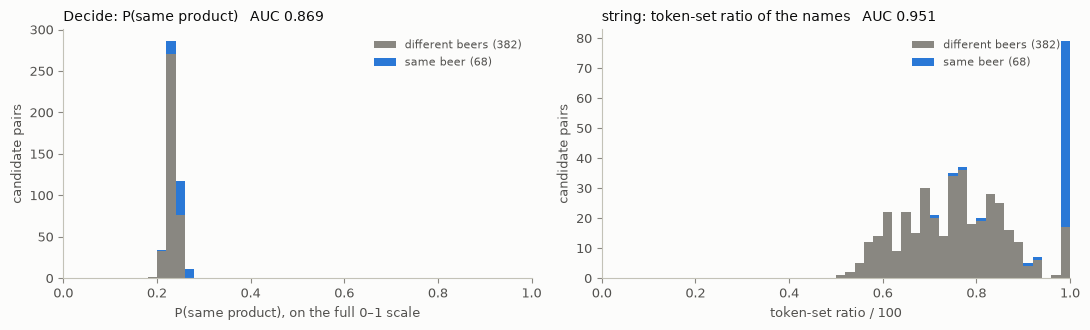

the ten pairs Decide finds most likely to be the same product:


,P(same product),known_same_as,entity_a,entity_b
id,,,,
c048,0.274,True,Heavyweight Ticklefight Champion Of The World,Solemn Oath Heavyweight Ticklefight Champion of the World
c256,0.268,True,Unite Red Rye Ale,Pike Unite Red Rye Ale
c037,0.267,True,Hearthstone Red Rye Ale,Hearthstone Red Rye Ale
c229,0.267,True,Dark Horse Amber Ale,Dark Horse Amber Ale
c228,0.265,True,Copperhead Amber Ale,Yalobusha Copperhead Amber Ale
c346,0.265,True,Willimantic Riverfest Red,Willimantic Riverfest Red Ale
c426,0.265,True,Willoughby American Amber Ale,Willoughby American Amber Ale
c148,0.262,True,Regimental 80 Scottish Ale,Crooked Eye Regimental 80 Scottish Ale
c405,0.261,True,Bushfire American Red,Granite Falls Bushfire American Red Ale


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), facecolor=SURFACE)
for ax, (name, values, xlim) in zip(axes, [
        ("Decide: P(same product)", SIGNALS["Decide: P(same product)"], (0, 1)),
        ("string: token-set ratio of the names", SIGNALS["string: token-set ratio of the names"], (0, 1))]):
    ax.set_facecolor(SURFACE)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelcolor=INK2, labelsize=9)
    # stacked, so a bin holding both classes shows both
    ax.hist([[v for v, g in zip(values, GOLD) if not g], [v for v, g in zip(values, GOLD) if g]],
            bins=[i / 100 for i in range(0, 101, 2)], stacked=True, color=[MUTED, BLUE],
            label=[f"different beers ({GOLD.count(False)})", f"same beer ({GOLD.count(True)})"])
    ax.set_xlim(*xlim)
    ax.set_title(f"{name}   AUC {ka.auc(values, GOLD):.3f}", loc="left", color=INK, fontsize=10)
    ax.set_ylabel("candidate pairs", color=INK2, fontsize=9)
    ax.legend(frameon=False, labelcolor=INK2, fontsize=8, loc="upper right")
axes[0].set_xlabel("P(same product), on the full 0–1 scale", color=INK2, fontsize=9)
axes[1].set_xlabel("token-set ratio / 100", color=INK2, fontsize=9)
plt.tight_layout()
plt.show()

top = sorted(judged, key=lambda j: -j.p_top)[:10]
print("the ten pairs Decide finds most likely to be the same product:")
display(pd.DataFrame([{"id": j.pair_id, "P(same product)": round(j.p_top, 3),
                       "known_same_as": BY_ID[j.pair_id]["known_same_as"],
                       "entity_a": BY_ID[j.pair_id]["entity_a"]["name"],
                       "entity_b": BY_ID[j.pair_id]["entity_b"]["name"]} for j in top]).set_index("id"))

On the full probability scale, Decide's answers are one narrow spike: every pair, match or not, between
about 0.2 and 0.3. Inside the spike the order is right more often than not, and the ten pairs it rates
highest are all true matches. The string ratio spreads the same pairs across the whole axis. It has its own
failure — a stack of non-matches at exactly 1.0, which §5 comes back to — but it puts its values where a
cut point can find them.

### 3.1 The `Noul`s, where the answer is not in doubt

The cookbook's `Noul`s exist to tell the curator *which field* disagrees. The cleanest test is the pairs
where a field is the same string on both sides: the right answer to *do the two entities state the same
beer name?* is then plainly yes.

In [9]:
rows = []
for field, qid in (("name", "same_name"), ("brewery", "same_brewery"), ("style", "same_style")):
    same = [JUDGED[p["id"]].properties[qid] for p in PAIRS if p["entity_a"][field] == p["entity_b"][field]]
    diff = [JUDGED[p["id"]].properties[qid] for p in PAIRS if p["entity_a"][field] != p["entity_b"][field]]
    span = lambda v: f"{min(v):.2f} – {max(v):.2f}" if v else "—"
    rows.append({"field": field, "pairs with identical strings": len(same),
                 "P(yes) when identical": span(same), "P(yes) when they differ": span(diff),
                 "pairs answered yes (P ≥ 0.5)": sum(p >= 0.5 for p in same + diff)})
display(pd.DataFrame(rows).set_index("field"))

,pairs with identical strings,P(yes) when identical,P(yes) when they differ,pairs answered yes (P ≥ 0.5)
field,,,,
name,12,0.34 – 0.45,0.30 – 0.44,0
brewery,28,0.41 – 0.66,0.24 – 0.65,54
style,0,—,0.36 – 0.49,0


Twelve pairs carry byte-identical names, and Decide answers *no* on every one, over a range that almost
coincides with its range for names that differ. The brewery question is the only one that ever says yes,
and it says yes to some pairs with different breweries while saying no to some with identical ones. The
style question cannot be checked this way at all: the two sites use different style vocabularies
(`American Barleywine` against `Barley Wine`), so no pair has identical styles. That is the case where a
model reading the question can still answer — Jev put `c446`'s two style names at 0.81 — and a string
comparison cannot.

---

## 4. How much of that is the wording?

Notebook 15 found three things about Decide's wording that matter more than any threshold: the label set
is the question, short concept labels beat long criteria, and the task name is part of the prompt. So
before concluding anything about the model, give it its own idiom. Each variant below changes one thing
from §2's schema.

In [10]:
from gliner2.classification import ClassificationSchema

SHORT = list(ka.LEVEL_LABELS)

def pipe_lines(pair):
    f = lambda e: " | ".join(e[k] for k in ("name", "brewery", "style", "abv"))
    return f"A: {f(pair['entity_a'])}\nB: {f(pair['entity_b'])}"

VARIANTS = {
    "the cookbook's four questions (§2)": None,
    "the Score alone, no Nouls in the prompt": dict(schema=ka.cookbook_schema(nouls=False)),
    "short labels, no descriptions, no instruction": dict(schema=ClassificationSchema().single(ka.LINK_TASK, SHORT)),
    "   … and task name 'match'": dict(schema=ClassificationSchema().single("match", SHORT), task="match"),
    "   … and task name 'duplicate'": dict(schema=ClassificationSchema().single("duplicate", SHORT), task="duplicate"),
    "two labels: different / same product": dict(
        schema=ClassificationSchema().single(ka.LINK_TASK, [SHORT[0], SHORT[2]]), labels=[SHORT[0], SHORT[2]]),
    "yes/no: do they describe the same product?": dict(
        schema=ClassificationSchema().single("answer", ["yes", "no"],
                                             instruction="Do the two entities describe the same product?"),
        task="answer", labels=["no", "yes"]),
    "the cookbook's four questions, as pipe-separated lines": dict(render=pipe_lines),
}

t0 = time.perf_counter()
runs = {name: judged if kw is None else ka.align(judge, PAIRS, **kw) for name, kw in VARIANTS.items()}
print(f"{len(VARIANTS) - 1} more passes over the 450 pairs in {time.perf_counter() - t0:.0f}s\n")

display(pd.DataFrame([{
    "shape": name,
    "P(same), lowest": min(j.p_top for j in js),
    "P(same), highest": max(j.p_top for j in js),
    "highest confidence": max(j.confidence for j in js),
    "to the curator": (f"{sum(j.outcome == 'curator queue' for j in js)}/{len(js)}"
                       if len(js[0].levels) == 3 else "—"),
    "AUC of P(same)": ka.auc([j.p_top for j in js], GOLD),
} for name, js in runs.items()]).set_index("shape").round(3))

7 more passes over the 450 pairs in 355s



,"P(same), lowest","P(same), highest",highest confidence,to the curator,AUC of P(same)
shape,,,,,
the cookbook's four questions (§2),0.193,0.274,0.232,450/450,0.869
"the Score alone, no Nouls in the prompt",0.140,0.236,0.384,450/450,0.908
"short labels, no descriptions, no instruction",0.162,0.297,0.394,450/450,0.928
… and task name 'match',0.138,0.284,0.483,449/450,0.894
… and task name 'duplicate',0.165,0.366,0.421,450/450,0.926
two labels: different / same product,0.150,0.478,0.700,—,0.869
yes/no: do they describe the same product?,0.256,0.403,0.488,—,0.713
"the cookbook's four questions, as pipe-separated lines",0.185,0.346,0.338,450/450,0.788


**No wording moves the probability onto a level.** Every three-level shape still sends essentially every
pair to the curator, and the two shapes with no middle level never put P(same) above one half. No
three-level shape reaches a confidence of 0.5 on any pair; the two-label shape does, but only ever on
`different product`.

The *ordering* does move with the wording, and the spread is the honest error bar on §3. Two findings from
notebook 15 reappear. The `Noul`s riding along in one prompt change the `Score`'s answer — asked alone, it
orders the pairs better — which is the price of "one request, four questions" on a model that encodes all
the tasks together. And short labels with no descriptions do at least as well as the cookbook's careful
criteria: the level wordings that are the whole decision for Jev are, for Decide, closer to noise. The
yes/no question over the pair is the weakest shape of all, as it was in notebook 15. Even the best row
orders the pairs less well than the string ratio.

---

## 5. The threshold the cookbook did not need

If the ordering is the usable part, the only way to route on it is a cut point, and a cut point on values
this compressed can only come from labelled data. The benchmark has a train split, so fit on the 268 train
pairs and look only at the 182 valid and test pairs, which the fit never sees.

The rule is the cookbook's asymmetry made numeric (`ka.fit_cuts`). A wrong merge is the expensive mistake,
so the upper cut is the highest value any train non-match reached: zero false merges on train. A missed
match only leaves a duplicate, so the lower cut lets 5% of train matches fall into `leave unlinked`.
Everything between goes to the curator.

In [11]:
TRAIN = [p["split"] == "train" for p in PAIRS]
HELD = [not t for t in TRAIN]

def fitted_routing(values):
    low, high = ka.fit_cuts([v for v, t in zip(values, TRAIN) if t],
                            [g for g, t in zip(GOLD, TRAIN) if t])
    held = [(ka.route_by_cuts(v, low, high), g) for v, g, h in zip(values, GOLD, HELD) if h]
    n = lambda outcome, match=None: sum(1 for r, g in held if r == outcome and (match is None or g == match))
    return {"low cut": low, "high cut": high,
            "merged": n("assert sameAs"), "… wrongly": n("assert sameAs", False),
            "to curator": n("curator queue"), "… of them matches": n("curator queue", True),
            "unlinked": n("leave unlinked"), "… matches missed": n("leave unlinked", True),
            "held-out AUC": ka.auc([v for v, h in zip(values, HELD) if h], [g for g, h in zip(GOLD, HELD) if h])}

CANDIDATES = {
    "Decide, cookbook's questions: score": scores,
    "Decide, cookbook's questions: P(same)": [j.p_top for j in judged],
    "Decide, the Score alone: P(same)": [j.p_top for j in runs["the Score alone, no Nouls in the prompt"]],
    "Decide, short labels: P(same)": [j.p_top for j in runs["short labels, no descriptions, no instruction"]],
    "string: token-set ratio of the names": SIGNALS["string: token-set ratio of the names"],
}
print(f"held out: {sum(HELD)} pairs (valid + test), {sum(g for g, h in zip(GOLD, HELD) if h)} of them matches\n")
display(pd.DataFrame([{"signal": name, **fitted_routing(v)} for name, v in CANDIDATES.items()])
        .set_index("signal").round(4))

held out: 182 pairs (valid + test), 28 of them matches



,low cut,high cut,merged,… wrongly,to curator,… of them matches,unlinked,… matches missed,held-out AUC
signal,,,,,,,,,
"Decide, cookbook's questions: score",0.8227,0.8860,1,1,168,28,13,0,0.7924
"Decide, cookbook's questions: P(same)",0.2310,0.2548,10,0,112,17,60,1,0.9100
"Decide, the Score alone: P(same)",0.1860,0.2057,20,5,93,12,69,1,0.9279
"Decide, short labels: P(same)",0.2458,0.2670,27,7,77,8,78,0,0.9434
string: token-set ratio of the names,0.7692,1.0000,0,0,94,28,88,0,0.9623


With a fitted threshold, Decide routes. On the cookbook's own wording, P(same) merges 10 held-out pairs
and gets every one right, sends 112 of the other 172 to the curator, and leaves one match unlinked. The
score — the quantity the cookbook actually routes on — is much worse, for the reason §3 gave: the middle
level pulls against the signal.

Three things make that result less than it looks. Look at the two cut columns: the whole decision sits
in a window about two hundredths of a probability wide, fitted to one draw of 268 pairs. The same rule applied
to two other wordings of the same question — each one ordering the pairs *better* than the cookbook's —
makes false merges on the held-out pairs, the one mistake the rule was built to avoid. A fitted cut belongs
to one wording, one model version and one data distribution; the cookbook's design exists so that none of
those needs refitting. Second, the curator still sees well over half the held-out pairs, against Jev's
one in nine. Third, the string ratio makes a different trade that is arguably the better one here: it never
merges, but it clears nearly half the held-out pairs as unlinked without losing a single match.

Why the string ratio never merges is worth a look, because it is the case the cookbook's middle level was
written for: a short name that sits whole inside a longer one — sometimes another brewery's beer,
sometimes a barrel-aged or fruited variant from the same brewery.

In [12]:
traps = [p for p, s in zip(PAIRS, SIGNALS["string: token-set ratio of the names"]) if s == 1.0 and not p["known_same_as"]]
print(f"{len(traps)} non-matches with a perfect token-set ratio on the names, e.g.:")
display(pd.DataFrame([{"id": p["id"], "entity_a": f"{p['entity_a']['name']}  ({p['entity_a']['brewery']})",
                       "entity_b": f"{p['entity_b']['name']}  ({p['entity_b']['brewery']})",
                       "Decide P(same)": round(JUDGED[p["id"]].p_top, 3)} for p in traps[:6]]).set_index("id"))
trap_p = [JUDGED[p["id"]].p_top for p in traps]
print(f"c428 among them: {any(p['id'] == 'c428' for p in traps)}")
print(f"Decide P(same) on all {len(traps)}: {min(trap_p):.3f} – {max(trap_p):.3f}, "
      f"against {min(j.p_top for j in judged):.3f} – {max(j.p_top for j in judged):.3f} over every pair")

17 non-matches with a perfect token-set ratio on the names, e.g.:


,entity_a,entity_b,Decide P(same)
id,,,
c125,Panama Limited Red Ale (Flossmoor Station Restaurant & ...,Flossmoor Station Barrel Aged Panama Limited Red Ale (F...,0.231
c132,Double Red Ale (The Seven Barrel Brewery),Midnight Sun Unite Double Red Hot Ale &#40; 2015 &#41; ...,0.215
c165,Barrel Aged Red Ale (BearWaters Brewing Co. .),Barley_s Barrel Aged Ulysses Imperial Red Ale (Barley_s...,0.239
c199,Road Rash Red (Tandem Brewing Company),Kettle House Bourbon Barrel Road Rash Imperial Red Ale ...,0.233
c247,Imperial Red Ale (Epic Brewing Company),ShuBrew Heart and Sole Imperial Red Ale (ShuBrew),0.234
c263,Fresh Hop Red (Liquid Mechanics Brewing Co. .),Ice Harbor Double Red Ale - Fresh Hop (Ice Harbor Brewi...,0.241


c428 among them: True
Decide P(same) on all 17: 0.207 – 0.250, against 0.193 – 0.274 over every pair


`c428` is one of them — the cookbook's own example of a variant, which Jev sent to the curator at 1.10.
These are the pairs where a model that reads the level wording earns its keep over a string comparison,
and they are pairs where Decide's answer sits in the middle of its range for everything else.

---

## 6. Jev on the same pairs

The cookbook publishes Jev's counts and four worked pairs, and never scores either against
`known_same_as`. Here Jev answers every pair: the cookbook's state and its `QUESTIONS` verbatim
(`ka.jev_questions()`), one request per pair, sent through `kgx.typesafe.CachedTypeSafe`, which stores each
response on disk. The first run makes 450 requests; every run after replays them, free and with no key.

One difference from the cookbook could not be avoided. Its numbers came from `jev-1.12`, which the API no
longer serves — asked for it by name on 2026-09-25, it answered `400 Unknown model` — so this run asks for
`jev-latest` and prints the version that answered. The key is read from `TYPESAFE_API_KEY` in the
environment or in the repo's `.env` (copy `.env.example`); with neither, and no cached responses, this
section skips itself.

In [13]:
from kgx.typesafe import CachedTypeSafe

JEV_MODEL = "jev-latest"   # the cookbook's jev-1.12 is no longer served; see above
jev = CachedTypeSafe(model=JEV_MODEL, cache_dir=ROOT / "output" / "typesafe_cache", timeout=120.0)
QUESTIONS = ka.jev_questions()
missing = sum(not jev.cached(ka.state(p), QUESTIONS) for p in PAIRS)
JEV_RUN = jev.available or missing == 0
print(jev)
print(f"{len(PAIRS) - missing} of {len(PAIRS)} pairs already in the cache")
if not JEV_RUN:
    print("\nNo TYPESAFE_API_KEY (environment or .env) and the cache is incomplete, so §6 is skipped.\n"
          "Copy .env.example to .env, add a key, and re-run this section.")

CachedTypeSafe(model='jev-latest', cache_dir='../output/typesafe_cache', key=set)
450 of 450 pairs already in the cache


In [14]:
if JEV_RUN:
    t0 = time.perf_counter()
    jev_judged = ka.ask_jev(jev, PAIRS, QUESTIONS)
    JEV_BY_ID = {j.pair_id: j for j in jev_judged}
    stats = jev.stats()
    print(f"asked for {JEV_MODEL!r}, answered by {jev.ask(ka.state(PAIRS[0]), QUESTIONS).model!r}")
    print(f"{len(jev_judged)} requests in {time.perf_counter() - t0:.1f}s: "
          f"{stats['requests_live']} live, {stats['requests_cached']} replayed from the cache")
    print(f"tokens: {sum(j.input_tokens for j in jev_judged):,} in, "
          f"{sum(j.output_tokens for j in jev_judged):,} out; "
          f"{stats['ms_per_request_observed']:.0f} ms a request when it was made\n")

    # the cookbook's four worked pairs: published, and as this run answered them
    display(pd.DataFrame([{
        "pair": pid,
        "published": f"{JEV[pid]['score']:.2f} / {JEV[pid]['confidence']:.2f}  ->  {ka.route(JEV[pid]['score'])}",
        "this run": f"{JEV_BY_ID[pid].score:.2f} / {JEV_BY_ID[pid].confidence:.2f}  ->  {JEV_BY_ID[pid].outcome}",
        "Nouls, published": "  ".join(f"{JEV[pid][q]:.2f}" for q in ka.NOULS),
        "Nouls, this run": "  ".join(f"{JEV_BY_ID[pid].properties[q]:.2f}" for q in ka.NOULS),
    } for pid in JEV]).set_index("pair"))

asked for 'jev-latest', answered by 'jev-1.13.0'
450 requests in 0.1s: 0 live, 450 replayed from the cache
tokens: 230,755 in, 31,950 out; 130 ms a request when it was made



,published,this run,"Nouls, published","Nouls, this run"
pair,,,,
c446,1.94 / 0.92 -> assert sameAs,1.95 / 0.93 -> assert sameAs,0.97 0.99 0.81,0.99 0.99 0.80
c427,0.03 / 0.95 -> leave unlinked,0.00 / 0.99 -> leave unlinked,0.02 0.09 0.08,0.01 0.01 0.02
c100,1.30 / 0.27 -> curator queue,1.31 / 0.47 -> curator queue,0.95 0.94 0.35,0.98 0.83 0.25
c428,1.10 / 0.77 -> curator queue,1.08 / 0.85 -> curator queue,0.63 0.98 0.74,0.08 0.99 0.85


The newer version answers the cookbook's four pairs the way the published one did: the same outcome
for each, and scores within a few hundredths. The differences are in what a curator would read. `c100`'s
confidence moves, and `c428`'s name `Noul` falls from 0.63 to 0.08 — *Ambleside Amber Ale* and *Bridge
Ambleside Amber Ale - Pomegranate & Galena Hops* are the same name to one version and not to the next. The
routing survives a model update here; the field-level explanation is less stable.

In [15]:
def outcome_table(judgments, keep=lambda pair: True):
    """Each outcome, split by the benchmark's answer."""
    rows = []
    for name in ("assert sameAs", "curator queue", "leave unlinked"):
        gold = [BY_ID[j.pair_id]["known_same_as"] for j in judgments
                if j.outcome == name and keep(BY_ID[j.pair_id])]
        rows.append({"outcome": name, "pairs": len(gold), "same beer": sum(gold),
                     "different beers": len(gold) - sum(gold)})
    return pd.DataFrame(rows).set_index("outcome")

if JEV_RUN:
    both = pd.concat({"Jev (this run)": outcome_table(jev_judged), "Decide": outcome_table(judged)}, axis=1)
    both.loc[:, ("Jev (published)", "pairs")] = [JEV_COUNTS[o] for o in both.index]
    display(both)
    merges = [j for j in jev_judged if j.outcome == "assert sameAs"]
    right = sum(BY_ID[j.pair_id]["known_same_as"] for j in merges)
    unlinked = sum(BY_ID[j.pair_id]["known_same_as"] for j in jev_judged if j.outcome == "leave unlinked")
    print(f"Jev's merges: {right} of {len(merges)} are the same beer; "
          f"{unlinked} of {sum(GOLD)} matches are left unlinked")
    near = lambda cut: sum(abs(j.score - cut) < 0.1 for j in jev_judged)
    print(f"pairs within 0.1 of a cut point: {near(0.5)} at 0.5, {near(1.5)} at 1.5 "
          f"(the cookbook, on jev-1.12: 47 and 9)")

Jev (this run)                           Decide                           Jev (published)
                        pairs same beer different beers  pairs same beer different beers           pairs
outcome                                                                                                 
assert sameAs              39        39               0      0         0               0              40
curator queue              38        25              13    450        68             382              50
leave unlinked            373         4             369      0         0               0             360

Jev's merges: 39 of 39 are the same beer; 4 of 68 matches are left unlinked
pairs within 0.1 of a cut point: 17 at 0.5, 6 at 1.5 (the cookbook, on jev-1.12: 47 and 9)


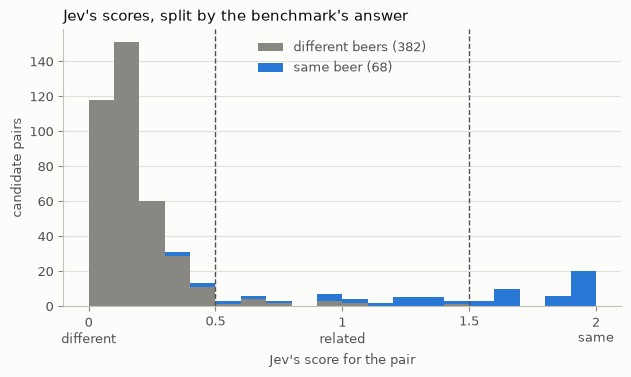

In [16]:
if JEV_RUN:
    jev_scores = [JEV_BY_ID[p["id"]].score for p in PAIRS]
    fig, ax = plt.subplots(figsize=(7.2, 3.6), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelcolor=INK2, labelsize=9)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.hist([[s for s, g in zip(jev_scores, GOLD) if not g], [s for s, g in zip(jev_scores, GOLD) if g]],
            bins=[i / 10 for i in range(21)], stacked=True, color=[MUTED, BLUE],
            label=[f"different beers ({GOLD.count(False)})", f"same beer ({GOLD.count(True)})"])
    for edge in (0.5, 1.5):
        ax.axvline(edge, color=INK2, linewidth=1, linestyle="--")
    ax.set_xticks([0, 0.5, 1, 1.5, 2])
    ax.set_xticklabels(["0\ndifferent", "0.5", "1\nrelated", "1.5", "2\nsame"])
    ax.set_xlabel("Jev's score for the pair", color=INK2, fontsize=9)
    ax.set_ylabel("candidate pairs", color=INK2, fontsize=9)
    ax.set_title("Jev's scores, split by the benchmark's answer", loc="left", color=INK, fontsize=11)
    ax.legend(frameon=False, labelcolor=INK2, fontsize=9)
    plt.show()

**Every one of Jev's merges is the same beer.** The benchmark agrees with all 39 pairs Jev routes to
`assert sameAs`: no false merge, the expensive mistake, and no threshold fitted to get there. The curator
gets 38 pairs, 25 of them matches, so two-thirds of the queue is real work. `leave unlinked` loses 4 of the
68 matches.

The counts are close to the published 40 / 50 / 360 but not equal, and the difference is at the lower cut
point: far fewer pairs sit near 0.5 than the cookbook counted on `jev-1.12`, so fewer go to the curator.
The histogram is what §2's chart looks like when a model places its answers on the levels: non-matches
piled up below the lower cut, most of the matches above the upper one, and a thin spread between.

In [17]:
def pair_row(pid):
    pair, j = BY_ID[pid], JEV_BY_ID[pid]
    return {"id": pid, "Jev score": j.score,
            "entity_a": f"{pair['entity_a']['name']}  ({pair['entity_a']['brewery']})",
            "entity_b": f"{pair['entity_b']['name']}  ({pair['entity_b']['brewery']})",
            "name": j.properties["same_name"], "brewery": j.properties["same_brewery"],
            "Decide P(same)": round(JUDGED[pid].p_top, 3)}

if JEV_RUN:
    wrong_merges = [j.pair_id for j in jev_judged
                    if j.outcome == "assert sameAs" and not BY_ID[j.pair_id]["known_same_as"]]
    missed = [j.pair_id for j in jev_judged
              if j.outcome == "leave unlinked" and BY_ID[j.pair_id]["known_same_as"]]
    print(f"merged, but the benchmark says different beers ({len(wrong_merges)}):")
    if wrong_merges:
        display(pd.DataFrame([pair_row(pid) for pid in wrong_merges]).set_index("id"))
    print(f"\nleft unlinked, but the benchmark says the same beer ({len(missed)}):")
    if missed:
        display(pd.DataFrame([pair_row(pid) for pid in missed]).set_index("id"))

merged, but the benchmark says different beers (0):

left unlinked, but the benchmark says the same beer (4):


,Jev score,entity_a,entity_b,name,brewery,Decide P(same)
id,,,,,,
c130,0.42,American Red Ale (Rock Art Brewery),Americas American Red Ale (Americas Brewpub),0.05,0.02,0.238
c217,0.37,Summer Session Ale (Elk Creek Cafe + Aleworks),Aqula Summer Session Ale (Aqula),0.07,0.02,0.241
c301,0.31,Rock Steady Red (The Rock Wood Fire Pizza & Brewery),Acoustic Rock Steady Red Cider (Acoustic Brewing Company),0.16,0.01,0.233
c329,0.45,Sierra Amber Ale (Silver Peak Restaurant & Brewery),Chy_e Sierra Amber Ale (Zamecky Pivovar Chy_e),0.14,0.02,0.243


There is no wrong merge to show. The four missed matches are worth reading, because in each the records
argue against the benchmark's label: every pair names two different breweries — Rock Art and Americas
Brewpub, Elk Creek Cafe and Aqula, a wood-fired pizza brewpub and Acoustic Brewing (whose entry is a
*cider*), Silver Peak and a Czech `pivovar` — and Jev's `same_brewery` is at most 0.02 on all four. They
read more like labelling errors in the benchmark than misses by the model. A notebook cannot settle which;
either way, a curator shown these pairs would have no evidence for a merge.

In [18]:
if JEV_RUN:
    JEV_SIGNALS = {
        "Jev: score": jev_scores,
        "Jev: P(same product)": [JEV_BY_ID[p["id"]].p_top for p in PAIRS],
        "Jev: same_name": [JEV_BY_ID[p["id"]].properties["same_name"] for p in PAIRS],
        "Jev: same_brewery": [JEV_BY_ID[p["id"]].properties["same_brewery"] for p in PAIRS],
        "Jev: same_style": [JEV_BY_ID[p["id"]].properties["same_style"] for p in PAIRS],
    }
    display(pd.DataFrame([{"signal": name, "lowest": min(v), "highest": max(v),
                           "AUC vs known_same_as": ka.auc(v, GOLD)}
                          for name, v in {**JEV_SIGNALS, **SIGNALS}.items()]).set_index("signal").round(3))

    rows = []
    for field, qid in (("name", "same_name"), ("brewery", "same_brewery")):
        ids = [p["id"] for p in PAIRS if p["entity_a"][field] == p["entity_b"][field]]
        span = lambda v: f"{min(v):.2f} – {max(v):.2f}"
        rows.append({"question": qid, "pairs with identical strings": len(ids),
                     "Jev": span([JEV_BY_ID[i].properties[qid] for i in ids]),
                     "Decide (§3.1)": span([JUDGED[i].properties[qid] for i in ids])})
    print("the answer to each field question, on the pairs where that field is the same string:")
    display(pd.DataFrame(rows).set_index("question"))

,lowest,highest,AUC vs known_same_as
signal,,,
Jev: score,0.000,1.980,0.992
Jev: P(same product),0.000,0.980,0.957
Jev: same_name,0.010,0.990,0.996
Jev: same_brewery,0.010,0.990,0.959
Jev: same_style,0.020,0.920,0.620
Decide: score (the cookbook's quantity),0.732,0.896,0.747
Decide: P(same product),0.193,0.274,0.869
"Decide: P(yes), same_name",0.302,0.448,0.880
"Decide: P(yes), same_brewery",0.239,0.664,0.855


the answer to each field question, on the pairs where that field is the same string:


,pairs with identical strings,Jev,Decide (§3.1)
question,,,
same_name,12,0.95 – 0.99,0.34 – 0.45
same_brewery,28,0.98 – 0.99,0.41 – 0.66


Scored against the same labels, Jev's score orders the pairs almost perfectly, where Decide's score
(the same quantity, from the same questions) sits well below the one-line string ratio. Jev's `same_name`
`Noul` on its own orders them about as well as its score: on this benchmark, whether the names match
nearly decides the pair, and the `Noul` that asks it is the one field-level answer a curator can lean on.
On the twelve pairs with identical names, where Decide said *no* to every one, Jev says *yes* at 0.95 or
more; on the identical breweries, likewise. The style `Noul` is weak for both models: the two catalogues
word styles differently even for the same beer, so a matching style is weak evidence either way.

In [19]:
if JEV_RUN:
    held_jev = [JEV_BY_ID[p["id"]] for p, h in zip(PAIRS, HELD) if h]
    t = outcome_table(held_jev)
    jev_row = {"low cut": 0.5, "high cut": 1.5,
               "merged": t.loc["assert sameAs", "pairs"], "… wrongly": t.loc["assert sameAs", "different beers"],
               "to curator": t.loc["curator queue", "pairs"], "… of them matches": t.loc["curator queue", "same beer"],
               "unlinked": t.loc["leave unlinked", "pairs"], "… matches missed": t.loc["leave unlinked", "same beer"],
               "held-out AUC": ka.auc([j.score for j in held_jev], [BY_ID[j.pair_id]["known_same_as"] for j in held_jev])}
    print(f"the {sum(HELD)} held-out pairs of §5; Jev's cuts are the cookbook's, fitted to nothing\n")
    display(pd.DataFrame([{"signal": "Jev: the cookbook's route (no fitting)", **jev_row}]
                         + [{"signal": name, **fitted_routing(v)} for name, v in CANDIDATES.items()])
            .set_index("signal").round(4))

the 182 held-out pairs of §5; Jev's cuts are the cookbook's, fitted to nothing



,low cut,high cut,merged,… wrongly,to curator,… of them matches,unlinked,… matches missed,held-out AUC
signal,,,,,,,,,
Jev: the cookbook's route (no fitting),0.5000,1.5000,18,0,16,8,148,2,0.9861
"Decide, cookbook's questions: score",0.8227,0.8860,1,1,168,28,13,0,0.7924
"Decide, cookbook's questions: P(same)",0.2310,0.2548,10,0,112,17,60,1,0.9100
"Decide, the Score alone: P(same)",0.1860,0.2057,20,5,93,12,69,1,0.9279
"Decide, short labels: P(same)",0.2458,0.2670,27,7,77,8,78,0,0.9434
string: token-set ratio of the names,0.7692,1.0000,0,0,94,28,88,0,0.9623


On the held-out pairs, the comparison §5 set up. Jev's cut points are 0.5 and 1.5 because that is where
the worded levels put them, fitted to nothing. It merges 18 held-out pairs, every one correctly, and
leaves two matches unlinked — both among the four above. The only Decide row with no false merge merges
10, and the two Decide rows that merge more do it with false merges. The difference that matters most is
the curator's queue: 16 pairs for Jev against 112 for that Decide row. The string ratio's lower cut clears
fewer pairs than Jev (88 against 148) without losing a match, and for free, but it never merges anything.

---

## 7. What this bought

**The translation is mechanical and it holds.** The cookbook's four questions become one Decide schema:
described labels for the `Score`, yes/no questions over the pair for the `Noul`s, one forward pass per
pair on a laptop CPU, no key, no cost per call. `kgx.alignment` keeps the cookbook's decision — levels,
outcomes, `route()` — as plain data beside the Decide schema, so the comparison is like for like.

**The routing rule does not survive the swap, and that says something about the rule.** "No threshold you
had to fit" is a property of the model, not of the recipe. On the same 450 pairs, with the same questions
and the same `route()`, Jev merges 39 pairs with no false merge and hands a curator 38; Decide hands the
curator all 450. The rule works when the model moves its probability onto the level whose wording fits,
and Decide's distributions over the three levels are nearly the same for every pair. This is notebook 15
§3.6's conclusion — Decide can label a text but not compare two — confirmed on a published benchmark, in
the format most favourable to it, beside the model the recipe was written for.

**What is left of Decide is an ordering, and it is not the best one available.** P(same) ranks matches
above non-matches well, and with a threshold fitted on labelled pairs it can route. But the threshold is
fragile across wordings, the curator's share stays high, and a one-line string ratio orders the pairs
better for free.

**The cookbook's numbers hold up when scored.** It never checks its routing against the benchmark's own
answer; done here, on a newer Jev, the merges are all right and the misses look like label noise. What does
not hold still is the model: `jev-1.12` is gone, `jev-latest` moved the lower cut point's population and
one of the four worked pairs' `Noul`s. The disk cache is what makes this notebook's Jev numbers
reproducible, not the alias.

### Where to take it

- **Block harder before asking Jev.** On the held-out pairs, the string ratio's fitted lower cut cleared
  nearly half the pairs without losing a match. Asking Jev only about the rest would cut the requests by
  about as much; whether it costs any of Jev's merges is one more table to compute.
- **Fine-tune Decide on the train split.** The model card points to the `gliner2` trainer. 268 labelled
  pairs is small, but the failure here is placement rather than ordering, which is what fine-tuning moves
  most easily. Score it on the same held-out pairs.
- **Use each tool where it measured well.** A string ratio to clear the obvious non-matches, Jev for the
  pair decision and the field-level `Noul`s a curator reads, and Decide where notebook 15 found it useful
  — checking a label against one text.